# 03 — SfM-only hyperparameter tuning and ablations

This notebook consumes a completed frozen feature cache. It must not re-extract backbone features and must not use RevisitOP labels.

It defaults to a 256-D descriptor. For the separate compactness ablation, set `FUSION_OUTPUT_DIM_OVERRIDE = 128` in the first code cell **before** starting a fresh run. The frozen cache is reused; the effective configuration and run fingerprint record the override.

In [1]:
# Run this first in every fresh Colab runtime.  It intentionally does not use PYTHONPATH.
from dataclasses import replace
from datetime import datetime, timezone
from pathlib import Path
import importlib
import os
import shutil
import subprocess
import sys

# Override this only if you use a fork/private clone URL.
REPO_URL = os.environ.get('CBIR_REPO_URL', 'https://github.com/armin-faraji/LightweightCBIR.git')
REPO_REVISION = os.environ.get('CBIR_REPO_REVISION', 'main')
# Leave as None for the reference 256-D experiment. Set to 128 only for a
# separate compactness ablation in a fresh Notebook 03 run.
FUSION_OUTPUT_DIM_OVERRIDE = None
PROJECT_ROOT = Path('/content/lightweight-cbir')
if not PROJECT_ROOT.is_dir():
    if not REPO_URL:
        raise RuntimeError('Set CBIR_REPO_URL before first use, or clone the repository to /content/lightweight-cbir.')
    subprocess.run(['git', 'clone', REPO_URL, str(PROJECT_ROOT)], check=True)
    subprocess.run(['git', '-C', str(PROJECT_ROOT), 'checkout', REPO_REVISION], check=True)
os.chdir(PROJECT_ROOT)
required_project_files = (PROJECT_ROOT / 'pyproject.toml', PROJECT_ROOT / 'src' / 'cbir' / '__init__.py', PROJECT_ROOT / 'src' / 'cbir' / 'artifacts.py')
missing_project_files = [str(path.relative_to(PROJECT_ROOT)) for path in required_project_files if not path.is_file()]
if missing_project_files:
    raise RuntimeError('The cloned repository does not contain the Colab-ready project code: ' + ', '.join(missing_project_files) + '. Push the current repository, or set CBIR_REPO_URL/CBIR_REPO_REVISION to the matching commit.')
# Do not use an editable install here: its .pth file is not automatically
# re-read by an already-running Jupyter kernel.
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', '--no-deps', '--force-reinstall', '.'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', 'h5py', 'scipy', 'PyYAML', 'tqdm', 'matplotlib', 'Pillow'], check=True)

importlib.invalidate_caches()
try:
    import cbir
except ModuleNotFoundError as error:
    raise RuntimeError('The package installation completed but cbir is not visible to this kernel. Restart the runtime once, then rerun this first cell.') from error
print('cbir package:', cbir.__file__)

from cbir.artifacts import create_artifact_run, make_artifact_run_id
from cbir.cloud import mount_colab_drive, runtime_report, write_runtime_report
from cbir.config import config_to_dict, load_project_config
from cbir.utils import stable_hash

PERSISTENT_ROOT = mount_colab_drive() / 'lightweight-cbir'
PERSISTENT_ROOT.mkdir(parents=True, exist_ok=True)
CONFIG_PATH = Path('configs/colab.yaml')
cfg = load_project_config(CONFIG_PATH)
output_dim_override = FUSION_OUTPUT_DIM_OVERRIDE
if output_dim_override is None:
    output_dim_override = os.environ.get('CBIR_FUSION_OUTPUT_DIM')
if output_dim_override is not None:
    try:
        output_dim_override = int(output_dim_override)
    except (TypeError, ValueError) as error:
        raise ValueError('FUSION_OUTPUT_DIM_OVERRIDE must be a positive integer or None') from error
    if output_dim_override <= 0:
        raise ValueError('FUSION_OUTPUT_DIM_OVERRIDE must be a positive integer or None')
    cfg = replace(cfg, fusion=replace(cfg.fusion, output_dim=output_dim_override))
environment = runtime_report(project_root=PROJECT_ROOT)
config_fingerprint = stable_hash(config_to_dict(cfg))
RUN_ID = make_artifact_run_id(notebook='03', git_sha=environment['git_sha'], config_fingerprint=config_fingerprint)
ARTIFACT_RUN = create_artifact_run(PROJECT_ROOT / 'outputs', '03', run_id=RUN_ID, metadata={'git_sha': environment['git_sha'], 'config_fingerprint': config_fingerprint})
LOCAL_OUTPUT_DIR = ARTIFACT_RUN.local_dir
DRIVE_OUTPUT_ROOT = PERSISTENT_ROOT / 'notebook_outputs'
write_runtime_report(LOCAL_OUTPUT_DIR, project_root=PROJECT_ROOT, extra={'notebook': '03', 'config': str(CONFIG_PATH), 'effective_fusion_output_dim': cfg.fusion.output_dim})
shutil.copy2(CONFIG_PATH, ARTIFACT_RUN.path_for('config.yaml'))
ARTIFACT_RUN.write_json('effective_config.json', config_to_dict(cfg))
ARTIFACT_RUN.write_json('experiment_overrides.json', {'fusion_output_dim_override': output_dim_override, 'effective_fusion_output_dim': cfg.fusion.output_dim})
print('Project:', PROJECT_ROOT)
print('Artifacts:', LOCAL_OUTPUT_DIR)
print('Fusion descriptor dimension:', cfg.fusion.output_dim)

Mounted at /content/drive
Project: /content/lightweight-cbir
Artifacts: /content/lightweight-cbir/outputs/03/20260803T195543Z__nb-03__git-17c84f56dc78__cfg-61e88f9438b7
Fusion descriptor dimension: 256


## Restore metadata and the completed frozen feature cache

Training never reads the many cache shards directly from Drive. It stages the small SfM metadata files, restores the validated full cache to fast `/content`, and retains its local shards in RAM so random pair batches do not repeatedly deserialize them.

In [2]:
from cbir.cache import FeatureShardReader
from cbir.cloud import publish_file, stage_file
from cbir.data.sfm import Sfm30kMetadata
from cbir.workflow import restore_complete_sfm_cache

LOCAL_SFM_ROOT = cfg.sfm.metadata_path.parent
DRIVE_SFM_ROOT = PERSISTENT_ROOT / 'datasets' / 'sfm30k'
metadata_files = (cfg.sfm.metadata_path, cfg.sfm.names_clusters_path)
LOCAL_SFM_ROOT.mkdir(parents=True, exist_ok=True)
if not all(path is not None and path.is_file() for path in metadata_files):
    if all(path is not None and (DRIVE_SFM_ROOT / path.name).is_file() for path in metadata_files):
        for path in metadata_files:
            assert path is not None
            stage_file(DRIVE_SFM_ROOT / path.name, path)
    else:
        subprocess.run([sys.executable, 'scripts/prepare_sfm30k.py', '--config', str(CONFIG_PATH), '--image-source', 'none'], cwd=PROJECT_ROOT, check=True)
        for path in metadata_files:
            assert path is not None
            publish_file(path, DRIVE_SFM_ROOT / path.name)
if cfg.sfm.names_clusters_path is None:
    raise ValueError('configs/colab.yaml must define sfm.names_clusters_path')
metadata = Sfm30kMetadata.from_official_files(cfg.sfm.metadata_path, cfg.sfm.names_clusters_path)
cache_location = restore_complete_sfm_cache(cfg, metadata)
reader = FeatureShardReader(cache_location.local_dir)
# Pair batches touch many shards in a random order. The complete float16 cache is
# small enough for this Colab RAM tier, so retain every local shard after its first read.
reader.max_cached_shards = len(reader.manifest.shards)
# Preload once here, rather than repeatedly stalling random training batches on deserialization.
warmup_ids = tuple(shard.image_ids[0] for shard in reader.manifest.shards)
_ = reader.fetch(warmup_ids, layer_indices=cfg.fusion.layer_indices, local_kind=cfg.fusion.local_kind)
del warmup_ids, _
if set(reader.image_ids) != set(metadata.image_ids()):
    raise RuntimeError('restored cache does not contain exactly the full SfM-30k protocol image IDs')
val_ids = metadata.image_ids('val')
val_cases = metadata.build_validation_cases()
ARTIFACT_RUN.write_json('cache_restore.json', {'cache_name': cache_location.cache_name, 'fingerprint': cache_location.fingerprint, 'local_dir': str(cache_location.local_dir), 'drive_dir': None if cache_location.drive_dir is None else str(cache_location.drive_dir)})
cache_size_gib = sum(shard.bytes for shard in reader.manifest.shards) / 2**30
print(f'Using restored cache: {cache_location.local_dir} ({len(reader.manifest.shards)} shards, {cache_size_gib:.2f} GiB retained in RAM)')

Using restored cache: /content/cbir_cache/sfm30k__dinov2-vits14-reg__c9263905d61e (115 shards, 0.74 GiB retained in RAM)


## Establish frozen CLS baseline

This is B0. Save its SfM R@1/R@5/R@10/MRR before trained heads are compared.

In [3]:
from cbir.evaluation import evaluate_sfm_verified_pairs, final_cls_descriptors_from_cache

baseline = final_cls_descriptors_from_cache(reader, val_ids)
baseline_report = evaluate_sfm_verified_pairs(baseline, val_ids, val_cases)
ARTIFACT_RUN.write_json('baseline_metrics.json', {
    'recall_at_1': baseline_report.recall_at_1,
    'recall_at_5': baseline_report.recall_at_5,
    'recall_at_10': baseline_report.recall_at_10,
    'mrr': baseline_report.mrr,
})
print(baseline_report)

SfmRetrievalReport(num_queries=1691, recall_at_1=0.9201655824955648, recall_at_5=0.9461856889414547, recall_at_10=0.9574216439976345, mrr=0.9336657129040622, ranks={'22826c9fc4f15fe329b6acb2e0802688': 1, '15b67c52c1d71895b9b1ca0cc1770989': 1, 'a6f1426fa88f3a9d78ebd80008562153': 1, '034509ca758765afb5d2acb8766c72ac': 1, '25cb5532e56e045a7af24b652469d897': 1, '29c62d3c6aa9f57972564d18214e9d47': 1, '074b69f95e6e8809623014c4a819bede': 1, '264913428fa7c8afc6f447af209e5083': 1, '28cb3c3a45889acbfda52c669552b71e': 1, '48f1a1dd1c7b318e9cb14f9abfb5bfeb': 1, '078092f6c77552f0221d70da6f5d193d': 1, '3090b4a85fa9663dec42b46ab7519a3a': 1, '24321968a41a70678f1bf7231b27664f': 1, '17f81d34f5e7fd9ac706454ac83069bd': 1, '11059d70410bd98d4ca9d433260e665f': 1, '4190afa1b84476541b99507b6391989e': 1, '273e096644f43e3e38aed6155663c47d': 1, 'd7212ca0cf8979670f2e2a8a457709c2': 1, '15911544854eb4de624927fc29e4c76c': 1, '9ca47f20b44b7bb65a11a098569f286f': 1, '02c736811970943854c2c89eff3b8578': 1, '905613a2597d225

## Causal gate ablation

Run uniform, static, and reliability modes with the same layer set/dimension/training budget. The cells below are intentionally independent, so a completed mode remains usable if a later mode fails or the runtime stops. Mean-vs-guided local pooling and last-only baselines are separate explicit configs, not hidden changes.

In [4]:
from dataclasses import replace

from cbir.cloud import publish_file
from cbir.config import config_to_dict, train_fingerprint
from cbir.fusion import ReliabilityGatedFusion
from cbir.plotting import SeriesData, plot_series
from cbir.training import HeadTrainer
from cbir.utils import seed_everything

# Keep the reference three modes fixed except for their gate rule. Each improved
# checkpoint is copied to Drive immediately, not deferred to the final cell.
GATE_MODES_TO_RUN = ('uniform', 'static', 'reliability')
LAST_THREE_LAYER_INDICES = tuple(range(cfg.backbone.num_blocks - 3, cfg.backbone.num_blocks))
if LAST_THREE_LAYER_INDICES != (9, 10, 11):
    raise RuntimeError(f'Expected a 12-block DINOv2 backbone, got last-three layers {LAST_THREE_LAYER_INDICES}')
PERSISTENT_CHECKPOINT_ROOT = PERSISTENT_ROOT / 'checkpoints' / '03' / ARTIFACT_RUN.run_id

def _history_payload(history):
    return {
        'epochs': history.epochs,
        'best_epoch': history.best_epoch,
        'best_metric': history.best_metric,
        'best_checkpoint': None if history.best_checkpoint is None else str(history.best_checkpoint),
    }

def run_fusion_experiment(experiment_name: str, *, gate_mode: str, layer_indices):
    if gate_mode not in {'uniform', 'static', 'reliability'}:
        raise ValueError(f'Unsupported gate mode: {gate_mode}')
    layer_indices = tuple(int(layer) for layer in layer_indices)
    if len(layer_indices) != 3 or len(set(layer_indices)) != 3:
        raise ValueError('Each three-layer experiment needs three distinct transformer blocks')
    if min(layer_indices) < 0 or max(layer_indices) >= cfg.backbone.num_blocks:
        raise ValueError(f'Layer indices are outside [0, {cfg.backbone.num_blocks - 1}]: {layer_indices}')
    fusion_cfg = replace(cfg.fusion, gate_mode=gate_mode, layer_indices=layer_indices)
    run_fingerprint = train_fingerprint(
        cache_fingerprint=reader.manifest.fingerprint,
        fusion=fusion_cfg,
        training=cfg.training,
    )
    local_run_dir = LOCAL_OUTPUT_DIR / 'runs' / experiment_name / run_fingerprint[:12]
    persistent_checkpoint = PERSISTENT_CHECKPOINT_ROOT / experiment_name / run_fingerprint[:12] / 'best.pt'

    def checkpoint_to_drive(local_checkpoint):
        publish_file(local_checkpoint, persistent_checkpoint)

    # Build every ablation head from the same RNG state; otherwise differences
    # in random initialization would be confounded with its gate or layer set.
    seed_everything(cfg.training.seed)
    trainer = HeadTrainer(
        head=ReliabilityGatedFusion.from_config(fusion_cfg),
        reader=reader,
        train_pairs=metadata.train_pairs,
        fusion_config=fusion_cfg,
        training_config=cfg.training,
        validation_cases=val_cases,
        validation_image_ids=val_ids,
        output_dir=local_run_dir,
        checkpoint_callback=checkpoint_to_drive,
    )
    history = trainer.fit()
    if history.best_checkpoint is None or not persistent_checkpoint.is_file():
        raise RuntimeError(f'{experiment_name} did not produce a durable best checkpoint')
    result = {
        'experiment_name': experiment_name,
        'gate_mode': gate_mode,
        'layer_indices': list(layer_indices),
        'run_fingerprint': run_fingerprint,
        'cache_fingerprint': reader.manifest.fingerprint,
        'fusion_config': config_to_dict(fusion_cfg),
        'training_config': config_to_dict(cfg.training),
        'persistent_checkpoint': str(persistent_checkpoint),
        **_history_payload(history),
    }
    ARTIFACT_RUN.write_json(f'runs/{experiment_name}/{run_fingerprint[:12]}/run_summary.json', result)
    return history, result

# Re-running this setup cell in the same runtime should not discard completed
# experiments; a fresh runtime naturally starts with empty dictionaries.
histories = globals().get('histories', {})
ablation_results = globals().get('ablation_results', {})

def write_gate_ablation_summary():
    ARTIFACT_RUN.write_json('gate_ablation.json', {
        'baseline': {
            'recall_at_1': baseline_report.recall_at_1,
            'recall_at_5': baseline_report.recall_at_5,
            'recall_at_10': baseline_report.recall_at_10,
            'mrr': baseline_report.mrr,
        },
        'runs': ablation_results,
    })

def record_fusion_experiment(experiment_name: str, *, gate_mode: str, layer_indices):
    history, result = run_fusion_experiment(
        experiment_name,
        gate_mode=gate_mode,
        layer_indices=layer_indices,
    )
    histories[experiment_name] = history
    ablation_results[experiment_name] = result
    write_gate_ablation_summary()
    print(f"{experiment_name}: best SfM validation R@1={result['best_metric']:.4f} at epoch {result['best_epoch'] + 1}")
    return history, result

def record_gate_mode(mode: str):
    return record_fusion_experiment(
        mode,
        gate_mode=mode,
        layer_indices=cfg.fusion.layer_indices,
    )

def record_last_three_variant(gate_mode: str):
    return record_fusion_experiment(
        f'{gate_mode}_last3',
        gate_mode=gate_mode,
        layer_indices=LAST_THREE_LAYER_INDICES,
    )

print('Run the three reference gate-mode cells below. The optional last-three-layer controls follow them.')

Run the three gate-mode cells below. Each one is safe to run independently after this setup cell.


### 1. Uniform gate

Uses equal weights for blocks 3, 7, and 11.

In [5]:
uniform_history, uniform_result = record_gate_mode('uniform')

uniform: best SfM validation R@1=0.9279 at epoch 22


### 2. Static gate

Learns one shared set of layer weights for every image.

In [6]:
static_history, static_result = record_gate_mode('static')

static: best SfM validation R@1=0.9279 at epoch 22


### 3. Reliability gate

Learns shared base weights and adjusts them per image using cached pooling entropy.

In [7]:
reliability_history, reliability_result = record_gate_mode('reliability')

reliability: best SfM validation R@1=0.9279 at epoch 22


## Optional late-layer control: blocks 9, 10, and 11

This tests the final three transformer blocks (`[9, 10, 11]`) at the same descriptor dimension (256-D in the recorded reference run), seed, pairs, schedule, and frozen cache as the reference `[3, 7, 11]` experiments. Run **all three** cells: `uniform_last3` isolates the layer-selection effect; `static_last3` tests fixed learned layer preference; and `reliability_last3` tests the additional per-image entropy adjustment. No new backbone extraction is required.

In [ ]:
uniform_last3_history, uniform_last3_result = record_last_three_variant('uniform')

In [ ]:
static_last3_history, static_last3_result = record_last_three_variant('static')

In [ ]:
reliability_last3_history, reliability_last3_result = record_last_three_variant('reliability')

## Audit the executed experiments before interpretation

Run this after the three reference modes and, if desired, the two last-three-layer controls. It compares the recorded histories exactly, reads the saved best checkpoints, and measures their learned gate weights on one fixed validation sample. It does not train or lock a model. The JSON report and large report-ready figures make it possible to distinguish a real tie from an inert gate or a layer-selection effect.

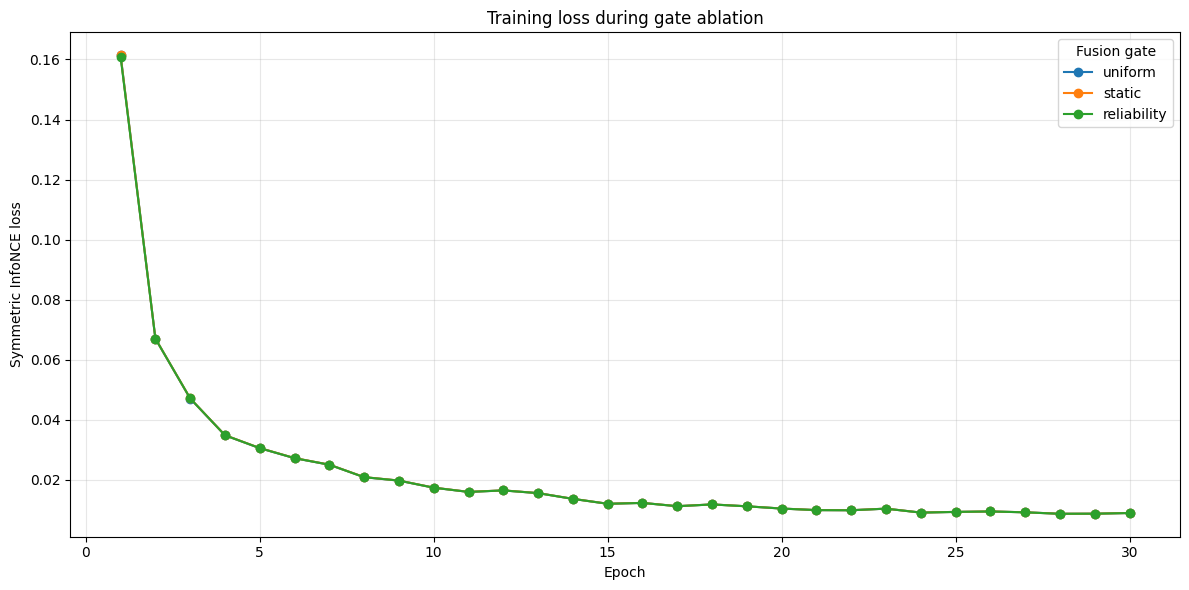

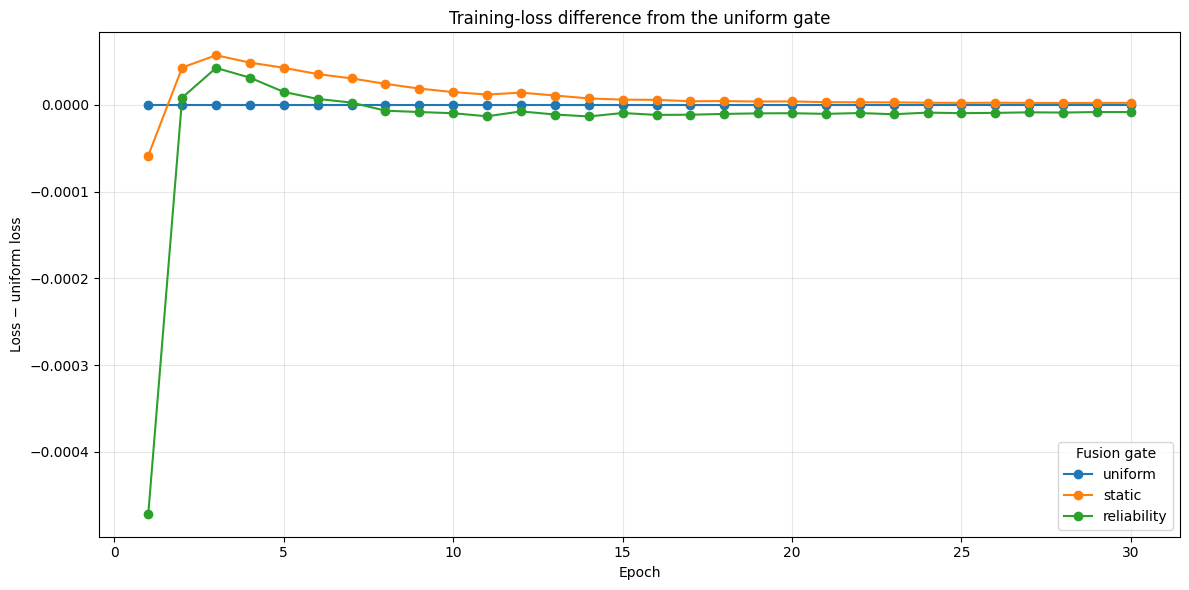

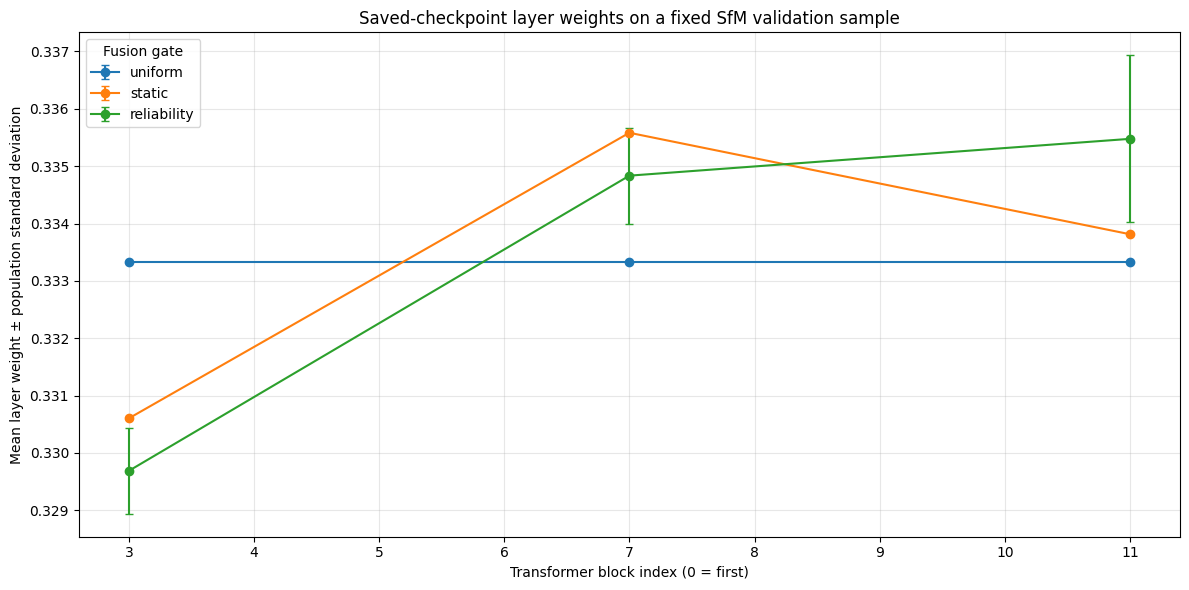

Wrote gate_integrity_diagnostics.json
uniform__vs__static: loss exact_equal=False, max |Δ|=5.857286133895134e-05, first differing epoch=1
uniform__vs__reliability: loss exact_equal=False, max |Δ|=0.00047118423211550686, first differing epoch=1
static__vs__reliability: loss exact_equal=False, max |Δ|=0.0004126113707765555, first differing epoch=1


In [8]:
from itertools import combinations

import numpy as np
import torch
import torch.nn.functional as functional
import matplotlib.pyplot as plt
from IPython.display import display

from cbir.cache import sha256_file
from cbir.config import FusionConfig

missing_modes = sorted(set(GATE_MODES_TO_RUN) - set(ablation_results))
if missing_modes:
    raise RuntimeError('Run every gate-mode cell before diagnostics: ' + ', '.join(missing_modes))
EXPERIMENT_NAMES = tuple(histories)
if set(EXPERIMENT_NAMES) != set(ablation_results):
    raise RuntimeError('histories and saved experiment results are inconsistent')

def compare_history_metric(left_history, right_history, metric):
    left_values = np.asarray([epoch[metric] for epoch in left_history.epochs], dtype=np.float64)
    right_values = np.asarray([epoch[metric] for epoch in right_history.epochs], dtype=np.float64)
    compared = min(len(left_values), len(right_values))
    absolute_difference = np.abs(left_values[:compared] - right_values[:compared])
    differing = np.flatnonzero(absolute_difference != 0)
    if differing.size:
        first_differing_epoch = int(left_history.epochs[int(differing[0])]['epoch']) + 1
    elif len(left_values) != len(right_values):
        first_differing_epoch = compared + 1
    else:
        first_differing_epoch = None
    return {
        'exact_equal': bool(len(left_values) == len(right_values) and np.array_equal(left_values, right_values)),
        'left_epoch_count': int(len(left_values)),
        'right_epoch_count': int(len(right_values)),
        'compared_epoch_count': int(compared),
        'max_abs_difference': float(absolute_difference.max()) if compared else None,
        'mean_abs_difference': float(absolute_difference.mean()) if compared else None,
        'first_differing_epoch': first_differing_epoch,
    }

def compare_state_dicts(left_state, right_state):
    left_keys = set(left_state)
    right_keys = set(right_state)
    common_keys = sorted(left_keys & right_keys)
    maximum = max(
        (float((left_state[key].detach().cpu() - right_state[key].detach().cpu()).abs().max()) for key in common_keys),
        default=0.0,
    )
    exact_equal = left_keys == right_keys and all(torch.equal(left_state[key], right_state[key]) for key in common_keys)
    return {
        'exact_equal': bool(exact_equal),
        'max_abs_difference': maximum,
        'left_only_keys': sorted(left_keys - right_keys),
        'right_only_keys': sorted(right_keys - left_keys),
        'common_tensor_count': len(common_keys),
    }

history_comparisons = {}
for left_mode, right_mode in combinations(EXPERIMENT_NAMES, 2):
    history_comparisons[f'{left_mode}__vs__{right_mode}'] = {
        metric: compare_history_metric(histories[left_mode], histories[right_mode], metric)
        for metric in ('loss', 'val_recall_at_1', 'lambda')
    }

checkpoint_payloads = {}
checkpoint_summaries = {}
for mode in EXPERIMENT_NAMES:
    checkpoint_path = Path(ablation_results[mode]['persistent_checkpoint'])
    if not checkpoint_path.is_file():
        raise FileNotFoundError(f'Missing durable {mode} checkpoint: {checkpoint_path}')
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    checkpoint_payloads[mode] = checkpoint
    saved_fusion_config = dict(checkpoint['fusion_config'])
    base_logits = checkpoint['model_state_dict']['base_logits'].detach().cpu()
    gate_raw = checkpoint['model_state_dict']['gate_raw'].detach().cpu()
    effective_lambda = functional.softplus(gate_raw) if saved_fusion_config['gate_mode'] == 'reliability' else torch.zeros_like(gate_raw)
    checkpoint_summaries[mode] = {
        'path': str(checkpoint_path),
        'sha256': sha256_file(checkpoint_path),
        'saved_epoch': int(checkpoint['epoch']) + 1,
        'saved_gate_mode': saved_fusion_config['gate_mode'],
        'output_dim': int(saved_fusion_config['output_dim']),
        'trainable_parameter_count': int(sum(value.numel() for value in checkpoint['model_state_dict'].values())),
        'base_logits': [float(value) for value in base_logits.tolist()],
        'centered_base_logits': [float(value) for value in (base_logits - base_logits.mean()).tolist()],
        'gate_raw': float(gate_raw),
        'effective_lambda': float(effective_lambda),
    }

checkpoint_state_comparisons = {
    f'{left_mode}__vs__{right_mode}': compare_state_dicts(
        checkpoint_payloads[left_mode]['model_state_dict'],
        checkpoint_payloads[right_mode]['model_state_dict'],
    )
    for left_mode, right_mode in combinations(EXPERIMENT_NAMES, 2)
}

sample_image_ids = tuple(val_ids[: min(512, len(val_ids))])
if not sample_image_ids:
    raise RuntimeError('Validation sample is empty')
gate_weight_statistics = {}
sample_descriptors = {}
for mode in EXPERIMENT_NAMES:
    checkpoint = checkpoint_payloads[mode]
    raw_fusion_config = dict(checkpoint['fusion_config'])
    raw_fusion_config['layer_indices'] = tuple(raw_fusion_config['layer_indices'])
    saved_fusion_config = FusionConfig(**raw_fusion_config)
    head = ReliabilityGatedFusion.from_config(saved_fusion_config)
    head.load_state_dict(checkpoint['model_state_dict'])
    head = head.to(cfg.training.device).eval()
    sample_features = reader.fetch(
        sample_image_ids,
        layer_indices=saved_fusion_config.layer_indices,
        local_kind=saved_fusion_config.local_kind,
    )
    sample_features = {name: value.to(cfg.training.device) for name, value in sample_features.items()}
    with torch.inference_mode():
        descriptor, diagnostics = head(
            sample_features['cls'],
            sample_features['local'],
            sample_features['entropy'],
            return_diagnostics=True,
        )
    weights = diagnostics.layer_weights.detach().cpu()
    entropy = sample_features['entropy'].detach().cpu()
    gate_weight_statistics[mode] = {
        'sample_image_count': len(sample_image_ids),
        'per_layer': [
            {
                'layer_index': int(layer_index),
                'weight_mean': float(weights[:, position].mean()),
                'weight_std': float(weights[:, position].std(unbiased=False)),
                'weight_min': float(weights[:, position].min()),
                'weight_max': float(weights[:, position].max()),
                'entropy_mean': float(entropy[:, position].mean()),
                'entropy_std': float(entropy[:, position].std(unbiased=False)),
            }
            for position, layer_index in enumerate(saved_fusion_config.layer_indices)
        ],
    }
    sample_descriptors[mode] = descriptor.detach().cpu()
    del head, sample_features

descriptor_comparisons = {
    f'{left_mode}__vs__{right_mode}': {
        'mean_cosine_similarity': float(functional.cosine_similarity(sample_descriptors[left_mode], sample_descriptors[right_mode], dim=1).mean()),
        'max_abs_difference': float((sample_descriptors[left_mode] - sample_descriptors[right_mode]).abs().max()),
    }
    for left_mode, right_mode in combinations(EXPERIMENT_NAMES, 2)
}

loss_delta_series = {}
uniform_loss_by_epoch = {int(epoch['epoch']) + 1: epoch['loss'] for epoch in histories['uniform'].epochs}
for mode in EXPERIMENT_NAMES:
    loss_by_epoch = {int(epoch['epoch']) + 1: epoch['loss'] for epoch in histories[mode].epochs}
    common_epochs = sorted(set(uniform_loss_by_epoch) & set(loss_by_epoch))
    loss_delta_series[mode] = SeriesData(
        x=common_epochs,
        y=[loss_by_epoch[epoch] - uniform_loss_by_epoch[epoch] for epoch in common_epochs],
    )

large_loss_series = {
    mode: SeriesData(
        x=[int(epoch['epoch']) + 1 for epoch in history.epochs],
        y=[epoch['loss'] for epoch in history.epochs],
    )
    for mode, history in histories.items()
}
weight_summary_series = {
    mode: SeriesData(
        x=[layer['layer_index'] for layer in statistics['per_layer']],
        y=[layer['weight_mean'] for layer in statistics['per_layer']],
        yerr=[layer['weight_std'] for layer in statistics['per_layer']],
    )
    for mode, statistics in gate_weight_statistics.items()
}
figure_large_loss, _ = plot_series(
    large_loss_series,
    title='Training loss during layer-selection and gate ablations',
    xlabel='Epoch',
    ylabel='Symmetric InfoNCE loss',
    legend_title='Experiment configuration',
    fig_size=(12, 6),
    save_path=ARTIFACT_RUN.path_for('figures/gate_ablation_loss_large.png'),
)
figure_loss_delta, _ = plot_series(
    loss_delta_series,
    title='Training-loss difference from the spaced uniform reference',
    xlabel='Epoch',
    ylabel='Loss − uniform loss',
    legend_title='Experiment configuration',
    fig_size=(12, 6),
    save_path=ARTIFACT_RUN.path_for('figures/gate_ablation_loss_delta_from_uniform.png'),
)
figure_weights, _ = plot_series(
    weight_summary_series,
    title='Saved-checkpoint layer weights on a fixed SfM validation sample',
    xlabel='Transformer block index (0 = first)',
    ylabel='Mean layer weight ± population standard deviation',
    legend_title='Experiment configuration',
    fig_size=(12, 6),
    save_path=ARTIFACT_RUN.path_for('figures/gate_weight_summary.png'),
)
for figure in (figure_large_loss, figure_loss_delta, figure_weights):
    display(figure)
    plt.close(figure)

gate_integrity_diagnostics = {
    'sample_image_ids': list(sample_image_ids),
    'history_comparisons': history_comparisons,
    'checkpoints': checkpoint_summaries,
    'checkpoint_state_comparisons': checkpoint_state_comparisons,
    'gate_weight_statistics': gate_weight_statistics,
    'descriptor_comparisons': descriptor_comparisons,
}
ARTIFACT_RUN.write_json('gate_integrity_diagnostics.json', gate_integrity_diagnostics)
write_gate_ablation_summary()
print('Wrote gate_integrity_diagnostics.json')
for pair, comparison in history_comparisons.items():
    loss = comparison['loss']
    print(f"{pair}: loss exact_equal={loss['exact_equal']}, max |Δ|={loss['max_abs_difference']}, first differing epoch={loss['first_differing_epoch']}")

## Compare the completed layer-selection and gate ablations

{'uniform': 0.9278533412182141, 'static': 0.9278533412182141, 'reliability': 0.9278533412182141}


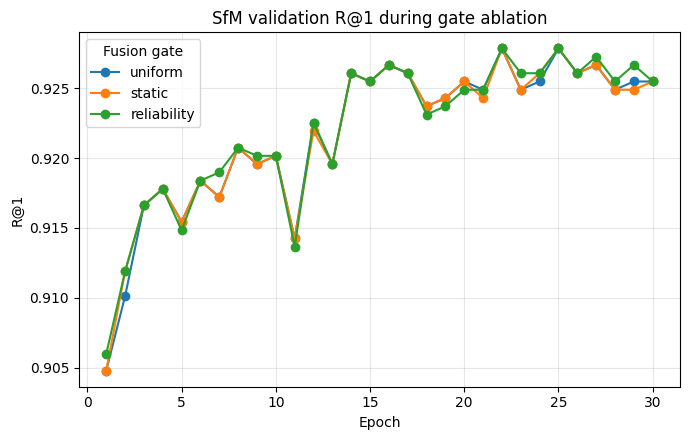

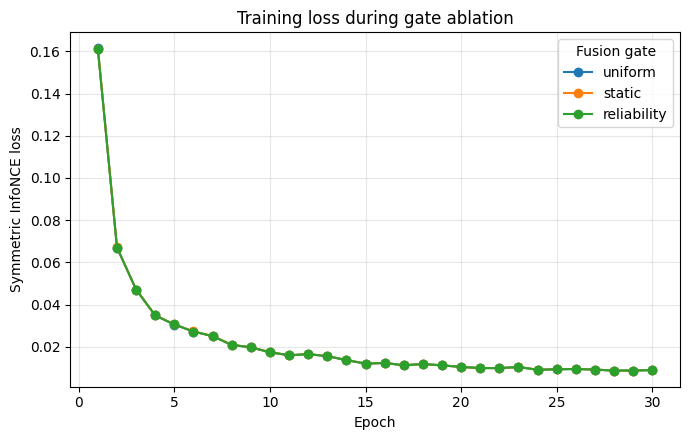

In [9]:
missing_modes = sorted(set(GATE_MODES_TO_RUN) - set(ablation_results))
if missing_modes:
    raise RuntimeError('Run every gate-mode cell before comparing or locking: ' + ', '.join(missing_modes))

write_gate_ablation_summary()
validation_series = {
    mode: SeriesData(
        x=[epoch['epoch'] + 1 for epoch in history.epochs],
        y=[epoch['val_recall_at_1'] for epoch in history.epochs],
    )
    for mode, history in histories.items()
}
loss_series = {
    mode: SeriesData(
        x=[epoch['epoch'] + 1 for epoch in history.epochs],
        y=[epoch['loss'] for epoch in history.epochs],
    )
    for mode, history in histories.items()
}
figure_r1, _ = plot_series(
    validation_series,
    title='SfM validation R@1 during layer-selection and gate ablations',
    xlabel='Epoch',
    ylabel='R@1',
    legend_title='Experiment configuration',
    save_path=ARTIFACT_RUN.path_for('figures/gate_ablation_validation_r1.png'),
)
figure_loss, _ = plot_series(
    loss_series,
    title='Training loss during layer-selection and gate ablations',
    xlabel='Epoch',
    ylabel='Symmetric InfoNCE loss',
    legend_title='Experiment configuration',
    save_path=ARTIFACT_RUN.path_for('figures/gate_ablation_loss.png'),
)
print({mode: result['best_metric'] for mode, result in ablation_results.items()})

## Lock the SfM-selected checkpoint and publish outputs

Set `LOCKED_MODE` only after comparing the SfM results above. This writes a durable lock that Notebook 04 reads; it must never be changed after looking at RevisitOP results. Then run the final publish cell exactly once after all desired plots/reports have been created.

In [10]:
from cbir.cache import sha256_file
from cbir.utils import atomic_write_json

# Change this to one completed experiment, for example 'reliability_last3', after inspecting SfM only.
LOCKED_MODE = None
if LOCKED_MODE is not None:
    missing_modes = sorted(set(GATE_MODES_TO_RUN) - set(ablation_results))
    if missing_modes:
        raise RuntimeError('Run every gate-mode cell before locking: ' + ', '.join(missing_modes))
    if LOCKED_MODE not in ablation_results:
        raise KeyError(f'{LOCKED_MODE!r} was not run in this notebook session')
    selected = ablation_results[LOCKED_MODE]
    persistent_checkpoint = Path(selected['persistent_checkpoint'])
    if not persistent_checkpoint.is_file():
        raise FileNotFoundError(f'Durable checkpoint is missing: {persistent_checkpoint}')
    lock = {
        'selected_on': 'SfM-30k validation only',
        'notebook_run_id': ARTIFACT_RUN.run_id,
        'cache_fingerprint': reader.manifest.fingerprint,
        'mode': LOCKED_MODE,
        'run_fingerprint': selected['run_fingerprint'],
        'best_epoch': selected['best_epoch'],
        'best_metric': selected['best_metric'],
        'fusion_config': selected['fusion_config'],
        'training_config': selected['training_config'],
        'checkpoint_path': str(persistent_checkpoint),
        'checkpoint_sha256': sha256_file(persistent_checkpoint),
    }
    lock_path = PERSISTENT_ROOT / 'locked' / 'locked_run.json'
    atomic_write_json(lock_path, lock)
    ARTIFACT_RUN.write_json('locked_selection.json', lock)
    print('Locked SfM-selected checkpoint:', persistent_checkpoint)
else:
    print('No checkpoint locked yet. Set LOCKED_MODE after choosing with SfM results only.')

No checkpoint locked yet. Set LOCKED_MODE after choosing with SfM results only.


## Publish notebook outputs to Drive

Run this as the final cell after training and, if applicable, locking. Best checkpoints were already copied to Drive at every improvement; this publishes figures, summaries, and environment provenance.

In [11]:
published_output = ARTIFACT_RUN.publish(DRIVE_OUTPUT_ROOT)
print('Validated notebook artifacts published to:', published_output)

Validated notebook artifacts published to: /content/drive/MyDrive/lightweight-cbir/notebook_outputs/03/20260803T195543Z__nb-03__git-17c84f56dc78__cfg-61e88f9438b7
